In [1]:
%load_ext autoreload

%autoreload 2

import sys
from pathlib import Path

# Ensure project imports work when launching the notebook from this subdirectory.
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "experiments.py").exists():
        path_str = str(candidate)
        if path_str not in sys.path:
            sys.path.insert(0, path_str)
        break
else:
    raise RuntimeError("Could not locate repository root")

import numpy as np
from tqdm.auto import tqdm

from lyapunov import has_lyapunov, bisection
from pepit_helpers import worst_case_performance
from plotting import line_plot
from utils import dask_parallel_map

# Numerical checks for Theorem 2 (EF)

This notebook numerically checks selected Theorem 2 formulas. Note: the current helper calls do not pass `n_workers=n`, so they use the helper default `n_workers=1` even though `n` is set below for the displayed multi-worker formulas. It compares:
- The predicted optimal step size
- The predicted worst-case convergence rate
- A Lyapunov candidate achieving the announced rate


In [2]:
# Experiment settings. The formulas below use common worker constants.
# The Lyapunov feasibility search is sensitive to PEP/SDP conditioning.
n = 2
L = 1.0
mu = 0.1
Ls = [L] * n
mus = [mu] * n
eps = 1e-2  # Lower bound for the epsilon sweep due to conditioning.
epsilons = np.linspace(eps, 1 - eps, num=10)
TOL = 1e-5

## Optimal step size
The theorem gives the following closed-form optimal step size for EF:
$$
\eta^\star = \left(\frac{2}{L+\mu}\right) \cdot \left(\frac{1 - \sqrt{\epsilon}}{1 + \sqrt{\epsilon}}\right).
$$
To sanity-check this numerically, we compute the best sampled worst-case contraction over the finite grid used below: sampled $\epsilon$ values in $[10^{-2}, 1 - 10^{-2}]$ and $\eta$ values in $[10^{-2}, 2/(L+\mu)]$. This is a grid comparison, not an exact optimizer; for $\epsilon$ close to 1, the theoretical $\eta^\star$ can fall below the grid lower endpoint.


In [3]:
optimal_step_sizes = []
GRID_RESOLUTION = 100
for epsilon in tqdm(epsilons):

    # Find the best sampled step size on the grid.
    step_sizes = np.linspace(eps, 2 / (L + mu), num=GRID_RESOLUTION)

    # Compute the contraction factors over those step sizes
    contractions = dask_parallel_map(
        lambda eta: bisection(0, 1, tol=TOL, solving_fun=has_lyapunov, delta=1 - epsilon, eta=eta, mus=mus, Ls=Ls, method="EF", use_residual=True)[0],
        step_sizes,
        show_progress=False
    )
    contractions = np.array([np.nan if c is None else c for c in contractions])
    best_eta = np.nan if np.all(np.isnan(contractions)) else step_sizes[np.nanargmin(contractions)]
    optimal_step_sizes.append(best_eta)

100%|██████████| 10/10 [00:31<00:00,  3.19s/it]


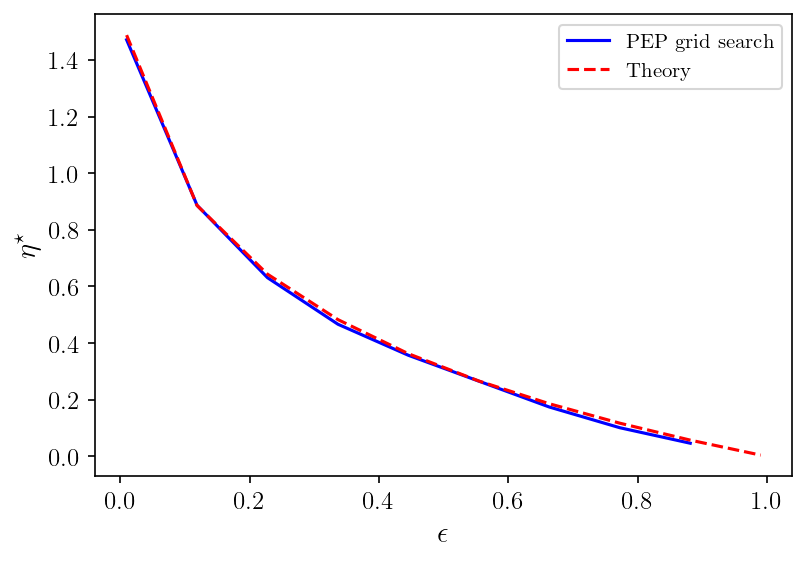

In [4]:
def theory_step_size(epsilon, L, mu):
    return 2 / (L + mu) * (1 - np.sqrt(epsilon)) / (1 + np.sqrt(epsilon))

theory = np.array([theory_step_size(epsilon, L, mu) for epsilon in epsilons])
data = [
    (epsilons, optimal_step_sizes, {"linestyle": "-", "label": "Lyapunov SDP grid search", "color": "blue"}),
    (epsilons, theory, {"linestyle": "--", "label": "Theory", "color": "red"})
]

line_plot(
    data,
    figsize=(6, 4),
    xlabel=r"$\epsilon$",
    ylabel=r"$\eta^\star$",
    plt_legend=True,
)

## Convergence rate
The theorem gives the following worst-case convergence rate:
$$
\rho^\star = \sqrt{\epsilon} + \left(\frac{1 - \sqrt{\epsilon}}{2}\right) \left(\frac{\kappa - 1}{\kappa + 1}\right)^2 \Psi(\kappa, \epsilon)
$$
where
$$
\Psi(\kappa, \epsilon) = 1 - \sqrt{\epsilon} + \sqrt{(1 + \sqrt{\epsilon})^2 + \sqrt{\epsilon}\, 16 \frac{\kappa}{(\kappa - 1)^2}}.
$$
To check this numerically, we use the closed-form step size, compute Lyapunov SDP bisection estimates for the sampled $\epsilon$ values, and compare those estimates with the formula in the plot below.


In [5]:
rho_measured = []
for epsilon in tqdm(epsilons):
    eta = theory_step_size(epsilon, L, mu)
    rho = bisection(0, 1, tol=TOL, solving_fun=has_lyapunov, delta=1 - epsilon, eta=eta, mus=mus, Ls=Ls, method="EF", use_residual=True)[0]
    rho_measured.append(rho)

100%|██████████| 10/10 [00:01<00:00,  6.03it/s]


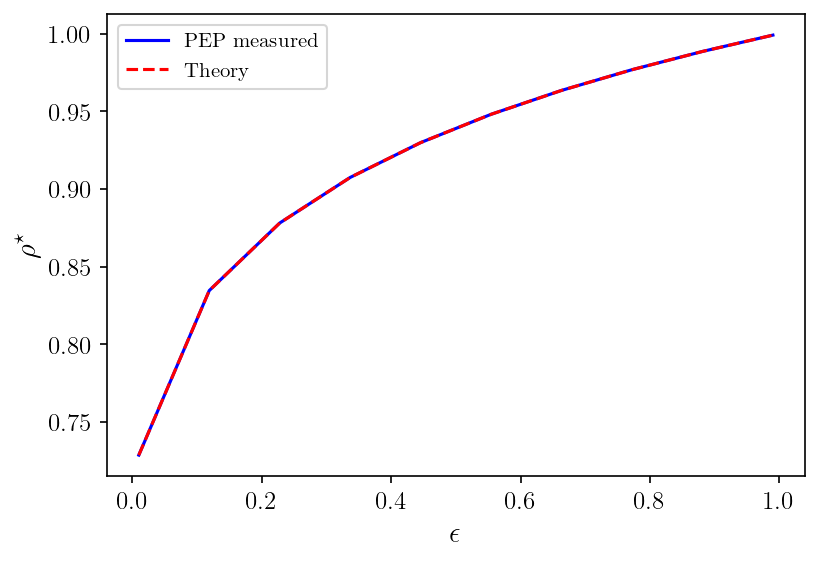

In [6]:
def theory_rate(epsilon, L, mu):
    sqrt_eps = np.sqrt(epsilon)
    kappa = L / mu
    psi = 1 - sqrt_eps + np.sqrt((1 + sqrt_eps)**2 + sqrt_eps * 16 * kappa / (kappa - 1)**2)
    return sqrt_eps + ((1 - sqrt_eps) / 2) * ((kappa - 1) / (kappa + 1))**2 * psi

# Compare Lyapunov SDP estimates with the theoretical convergence rates
rho_measured_np = np.array([
    r[0] if isinstance(r, tuple) else r for r in rho_measured
], dtype=float)

rho_theory = np.array([theory_rate(epsilon, L, mu) for epsilon in epsilons], dtype=float)

data = [
    (epsilons, rho_measured_np, {"linestyle": "-", "label": "Lyapunov SDP", "color": "blue"}),
    (epsilons, rho_theory, {"linestyle": "--", "label": "Theory", "color": "red"}),
]

line_plot(
    data,
    figsize=(6, 4),
    xlabel=r"$\epsilon$",
    ylabel=r"$\rho^\star$",
    plt_legend=True,
)

## Lyapunov function
The theorem gives the following simplified Lyapunov candidate for EF:
$$
\mathcal V\!\left(\xi^{\mathrm{EF}},x;f\right) = \frac{1}{n \sqrt{\epsilon}} \| \sum_{i=1}^n e^{(i)}_k \|^2 + \sum_{i=1}^n \|x_k - x_\star - e_k^{(i)}\|^2
$$
To check this numerically, we compare the rate from the unconstrained quadratic-Lyapunov search with the one-step PEPit worst-case performance obtained using this fixed simplified Lyapunov candidate, over the sampled $\epsilon$ values. The cell below plots the comparison; it does not print relative differences.


In [7]:
rhos_unconstrained = []
rhos_constrained = []
for epsilon in tqdm(epsilons):
    eta = theory_step_size(epsilon, L, mu)

    # First, estimate the best rate over the quadratic Lyapunov family encoded by has_lyapunov.
    rho_unconstrained = bisection(
        0, 1, tol=TOL, solving_fun=has_lyapunov, delta=1 - epsilon,
        eta=eta, mus=mus, Ls=Ls, method="EF", use_residual=True, homogenous=True
    )[0]
    rhos_unconstrained.append(rho_unconstrained)

    # Then compute the worst-case one-step contraction for the fixed simplified Lyapunov candidate.
    rho_constrained = worst_case_performance(
        mu=mus, L=Ls, eta=eta, delta=1 - epsilon,
        method="EF", n_iterations=1, use_simplified=True, homogenous=True
    )
    rhos_constrained.append(rho_constrained)

100%|██████████| 10/10 [00:01<00:00,  5.97it/s]


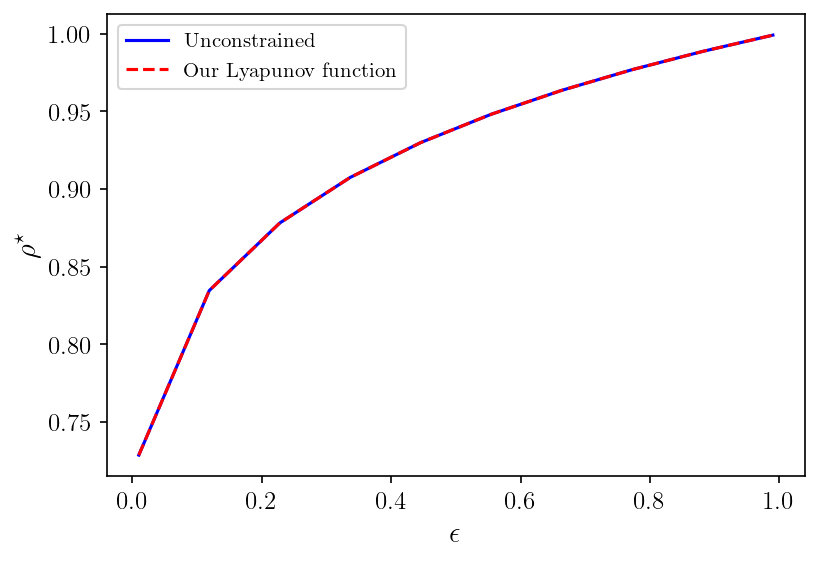

In [8]:
data = [
    (epsilons, rhos_unconstrained, {"linestyle": "-", "label": "Unconstrained Lyapunov search", "color": "blue"}),
    (epsilons, rhos_constrained, {"linestyle": "--", "label": "Fixed simplified Lyapunov", "color": "red"}),
]

line_plot(
    data,
    figsize=(6, 4),
    xlabel=r"$\epsilon$",
    ylabel=r"$\rho^\star$",
    plt_legend=True,
)